# 국민여행조사 3개년 전체 여행의 지역(시군구) 단위 집계

## 분석 목적과 범위

기존 `260720_연고관광_지역후보지_선정_2025년/3개년`은 응답자당
CHECK='Y'로 선택된 **대표 여행 1건**만 지역 단위로 펼쳤다. 이 방식은
대표 여행으로 선택되지 않는 CASE 3(단순 가족·친지·친구 방문)·CASE
5(단순 출장)의 실제 방문 지역 정보를 통째로 누락시킨다. 이 노트북은
`national_travel_survey_2023_2025_preprocessed_all_tour.csv`(응답자별
`D_TRA1~6_*` 여행 슬롯을 모두 보존한 파일)로 **모든 여행·모든
방문지**를 시군구 단위로 재집계한다.

집계 목적: 시군구별로 (1) 얼마나 많은 여행이 그 지역을 다녀갔는지,
(2) `WT_DOM`으로 확대한 실제 규모는 얼마인지, (3) CASE(여행유형)별로
이게 어떻게 나뉘는지, (4) 그 지역을 대표 여행으로 방문한 사람들의
A계열 응답 프로필은 어떤지를 표로 만든다.

## 분석 단위와 계산 방식

- 지역은 한 여행이 여러 곳을 방문할 수 있는 **다중응답**이고, CASE는
  여행 1건당 값이 하나뿐인 **배타적 파티션**이다. 지역별 소계의 합은
  전체 여행 수를 초과할 수 있지만(다중응답의 정상적 성질), CASE별
  소계의 합은 전체와 정확히 일치해야 한다.
- "가중 지역 규모" 지표는 `WT_DOM × (그 지역 체류일 / 그 여행의 체류일
  합)`을 지역별로 합산한 값 하나만 만든다(체류일 비례 안분, 합
  보존).
- 비중의 분모는 신고된 전체 여행일수(`D_TRA{k}_S_Day` + 1)가 아니라
  **그 여행 안에서 실제 계산된 방문지별 체류일의 합**을 쓴다. 이렇게
  해야 비중의 합이 항상 정확히 1이 되어 지역 합계가 전체 여행
  규모와 어긋나지 않는다. 신고된 전체 일수와의 차이는 별도 QC로만
  검증한다.
- A계열은 응답자당 대표 여행(`D_TRA{k}_CHECK=='Y'`) 1건에만 존재하며,
  이 대표 여행의 CASE는 실측 검증 결과 항상 1·2·4다(케이스 3·5는
  0건). A계열 지역 프로필 계산 시 별도 CASE 필터 없이 결측 제거만
  하면 자동으로 CASE 3·5가 빠진다. A계열 값은 그 대표 여행이 방문한
  지역 각각에 **체류일 비중을 나누지 않고 그대로** 배정한다.

## 환경, 공통 경로와 재현성 설정

In [ ]:
from pathlib import Path
import re
import sys
import warnings

current_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (current_directory, *current_directory.parents)
        if (candidate / "src" / "path.py").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "프로젝트 루트를 찾을 수 없습니다. 프로젝트 내부에서 실행하세요."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.path import (
    NATIONAL_TRAVEL_SURVEY_PREPROCESSED_DATA_DIR,
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR,
    OUTPUTS_DIR,
    create_output_directories,
)
from src.visualization import COLORS, PALETTE, apply_plot_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_plot_style()
NOTEBOOK_STEM = "260720_국민여행조사_지역별_전체여행_집계_3개년"
FIGURES_DIR, TABLES_DIR = create_output_directories(f"{NOTEBOOK_STEM}.ipynb")

DATA_PATH = (
    NATIONAL_TRAVEL_SURVEY_PREPROCESSED_DATA_DIR
    / "national_travel_survey_2023_2025_all_tour.csv"
)
CODEBOOK_PATH = (
    NATIONAL_TRAVEL_SURVEY_PREPROCESSED_DATA_DIR
    / "national_travel_survey_2023_2025_all_tour_codebook.csv"
)
REGION_CODE_PATH = (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR
    / "national_travel_survey_region_code.csv"
)
# 사전층화 클러스터링이 확정되면 이 경로만 최종 산출물로 바꾼다(13절 참고).
CLUSTER_LABELED_DATA_PATH = (
    OUTPUTS_DIR
    / "260720_연고관광_사전층화_클러스터링_3개년_v4"
    / "tables"
    / "baseline_stratified_cluster_labeled_data.csv"
)
TRIP_SLOTS = range(1, 7)
MAX_SPOT = 17

print(f"입력 원자료: {DATA_PATH.name}")
print(f"코드북: {CODEBOOK_PATH.name}")
print(f"지역코드: {REGION_CODE_PATH.name}")
print(f"군집 라벨(임시, 13절에서 사용): {CLUSTER_LABELED_DATA_PATH.name}")

입력 원자료: national_travel_survey_2023_2025_preprocessed_all_tour.csv
코드북: national_travel_survey_2023_2025_preprocessed_all_tour_codebook.csv
지역코드: national_travel_survey_region_code.csv
군집 라벨(임시, 13절에서 사용): baseline_stratified_cluster_labeled_data.csv


## 1. 로드·품질 확인

`data-guide.md`의 최소 품질 확인 체크리스트(`YEAR+ID` 유일성,
`WT_DOM` 결측·양수 확인)를 그대로 적용하고, 지역코드는
`시도_코드*1000+시군구_코드` 복합키로 5자리 `spot_code`를 만들어
229행 유일성을 확인한다.

In [2]:
codebook = pd.read_csv(CODEBOOK_PATH, encoding="utf-8-sig")
data = pd.read_csv(DATA_PATH, encoding="utf-8-sig", low_memory=False)

assert set(codebook["column_name"]) == set(data.columns), (
    "코드북과 all_tour 전처리본의 열 구성이 다릅니다."
)
assert data["ID"].notna().all(), "ID에 결측이 있습니다."
assert not data[["YEAR", "ID"]].duplicated().any(), "YEAR + ID 키가 중복됩니다."

weight = pd.to_numeric(data["WT_DOM"], errors="coerce")
assert weight.notna().all(), "WT_DOM에 결측이 있습니다."
assert weight.gt(0).all(), "WT_DOM에 0 이하 값이 있습니다."

region_codes = pd.read_csv(REGION_CODE_PATH, encoding="utf-8-sig")
assert not region_codes.duplicated(["시도_코드", "시군구_코드"]).any()
region_codes["spot_code"] = (
    region_codes["시도_코드"].astype(int) * 1000
    + region_codes["시군구_코드"].astype(int)
)
assert region_codes["spot_code"].is_unique
assert len(region_codes) == 229

print(f"all_tour 전처리본: {data.shape[0]:,}행 × {data.shape[1]:,}열")
print(f"지역코드: {len(region_codes)}개 시군구")

all_tour 전처리본: 156,050행 × 1,476열
지역코드: 229개 시군구


## 2. 여행(trip) 단위 long 변환

`D_TRA{k}_CASE`가 비결측인 슬롯(k=1~6)만 트립으로 인정하고, 키는
`YEAR + ID + TRIP_NO(k)`다. 트립별 `WT_DOM`, `CASE`, `CHECK`,
신고된 여행일수(`D_TRA{k}_S_Day` + 1, 단위 "박"이라 +1)를 보존한다.

In [3]:
def build_trip_long(frame: pd.DataFrame, slots) -> pd.DataFrame:
    '''여행 슬롯을 트립 단위 long 자료로 바꾼다.

    Args:
        frame: 응답자·조사회차 단위 all_tour 전처리본.
        slots: 여행 슬롯 번호(1~6).

    Returns:
        `YEAR`, `ID`, `TRIP_NO`, `WT_DOM`, `CASE`, `CHECK`,
        `reported_trip_days` 열을 가진 long 자료. `D_TRA{k}_CASE`가
        결측인 슬롯은 제외한다.
    '''
    frames = []
    for slot in slots:
        case = pd.to_numeric(frame[f"D_TRA{slot}_CASE"], errors="coerce")
        valid = case.notna()
        nights = pd.to_numeric(
            frame.loc[valid, f"D_TRA{slot}_S_Day"], errors="coerce"
        )
        frames.append(
            pd.DataFrame(
                {
                    "YEAR": frame.loc[valid, "YEAR"].to_numpy(),
                    "ID": frame.loc[valid, "ID"].to_numpy(),
                    "TRIP_NO": slot,
                    "WT_DOM": pd.to_numeric(
                        frame.loc[valid, "WT_DOM"], errors="coerce"
                    ).to_numpy(),
                    "CASE": case.loc[valid].to_numpy(),
                    "CHECK": frame.loc[valid, f"D_TRA{slot}_CHECK"].to_numpy(),
                    "reported_trip_days": (nights + 1).to_numpy(),
                }
            )
        )
    return pd.concat(frames, ignore_index=True)


trip_long = build_trip_long(data, TRIP_SLOTS)

assert not trip_long.duplicated(["YEAR", "ID", "TRIP_NO"]).any()
assert trip_long["CASE"].between(1, 5).all()

print(f"트립 단위 데이터: {len(trip_long):,}행")
print("슬롯별(=TRIP_NO) 트립 수:")
display(trip_long["TRIP_NO"].value_counts().sort_index())
print("CASE별 트립 수(다중응답 아님, 트립당 1개):")
display(trip_long["CASE"].value_counts().sort_index())

트립 단위 데이터: 84,673행
슬롯별(=TRIP_NO) 트립 수:


TRIP_NO
1    79730
2     4556
3      313
4       60
5       11
6        3
Name: count, dtype: int64

CASE별 트립 수(다중응답 아님, 트립당 1개):


CASE
1.0    59514
2.0    13107
3.0     8638
4.0     1518
5.0     1896
Name: count, dtype: int64

## 3. 방문지(spot) 단위 long 변환과 체류일 계산

각 트립 안에서 `D_TRA{k}_{j}_SPOT`(j=1~17, 존재하는 슬롯만)을
melt하고, 방문지별 `SYEAR/SMONTH/SDAY`~`EYEAR/EMONTH/EDAY`로
`region_days = (종료일 - 시작일).days + 1`을 계산한다. 음수·0
이하이거나 날짜 파싱에 실패하면 제외하고 QC로 별도 집계한다.

In [4]:
def compute_region_days(
    start_year, start_month, start_day, end_year, end_month, end_day,
):
    '''방문지 체류일을 시작일·종료일 차이로 계산한다.

    Args:
        start_year, start_month, start_day: 방문 시작일 연·월·일.
        end_year, end_month, end_day: 방문 종료일 연·월·일.

    Returns:
        (region_days, date_parse_failed) 튜플. `region_days`는 유효한
        날짜 쌍 중 1일 이상인 경우에만 값을 갖고 그 외에는 NaN이다.
        `date_parse_failed`는 시작일 또는 종료일 파싱에 실패했음을
        나타내는 불리언 Series다.
    '''
    start = pd.to_datetime(
        {"year": start_year, "month": start_month, "day": start_day},
        errors="coerce",
    )
    end = pd.to_datetime(
        {"year": end_year, "month": end_month, "day": end_day},
        errors="coerce",
    )
    date_parse_failed = start.isna() | end.isna()
    region_days = (end - start).dt.days + 1
    region_days = region_days.where(~date_parse_failed & region_days.gt(0))
    return region_days, date_parse_failed


def build_spot_long(frame: pd.DataFrame, slots, max_spot: int) -> pd.DataFrame:
    '''방문지 슬롯을 트립×방문지 단위 long 자료로 바꾸고 체류일을 계산한다.

    Args:
        frame: 응답자·조사회차 단위 all_tour 전처리본.
        slots: 여행 슬롯 번호(1~6).
        max_spot: 여행당 최대 방문지 슬롯 수(17).

    Returns:
        `YEAR`, `ID`, `TRIP_NO`, `SPOT_NO`, `spot_code`,
        `region_days`, `date_parse_failed` 열을 가진 long 자료.
        방문지 코드가 결측인 슬롯은 제외한다.
    '''
    frames = []
    for slot in slots:
        for spot in range(1, max_spot + 1):
            spot_column = f"D_TRA{slot}_{spot}_SPOT"
            if spot_column not in frame.columns:
                continue
            spot_code = pd.to_numeric(frame[spot_column], errors="coerce")
            valid = spot_code.notna()
            if not valid.any():
                continue
            prefix = f"D_TRA{slot}_{spot}_"
            region_days, date_parse_failed = compute_region_days(
                pd.to_numeric(frame.loc[valid, f"{prefix}SYEAR"], errors="coerce"),
                pd.to_numeric(frame.loc[valid, f"{prefix}SMONTH"], errors="coerce"),
                pd.to_numeric(frame.loc[valid, f"{prefix}SDAY"], errors="coerce"),
                pd.to_numeric(frame.loc[valid, f"{prefix}EYEAR"], errors="coerce"),
                pd.to_numeric(frame.loc[valid, f"{prefix}EMONTH"], errors="coerce"),
                pd.to_numeric(frame.loc[valid, f"{prefix}EDAY"], errors="coerce"),
            )
            frames.append(
                pd.DataFrame(
                    {
                        "YEAR": frame.loc[valid, "YEAR"].to_numpy(),
                        "ID": frame.loc[valid, "ID"].to_numpy(),
                        "TRIP_NO": slot,
                        "SPOT_NO": spot,
                        "spot_code": spot_code.loc[valid].astype(int).to_numpy(),
                        "region_days": region_days.to_numpy(),
                        "date_parse_failed": date_parse_failed.to_numpy(),
                    }
                )
            )
    return pd.concat(frames, ignore_index=True)


spot_long = build_spot_long(data, TRIP_SLOTS, MAX_SPOT)
print(f"방문지 슬롯 원본 행 수(dedup 전): {len(spot_long):,}행")
print(f"날짜 파싱 실패: {int(spot_long['date_parse_failed'].sum()):,}행")
print(
    "체류일 계산 실패(파싱 실패 포함, 음수·0 이하 포함): "
    f"{int(spot_long['region_days'].isna().sum()):,}행"
)

방문지 슬롯 원본 행 수(dedup 전): 143,329행
날짜 파싱 실패: 0행
체류일 계산 실패(파싱 실패 포함, 음수·0 이하 포함): 0행


## 4. 지역코드 결합

`spot_code`를 `region_codes`와 `many_to_one`으로 병합한다. 미매칭은
임의 보정 없이 `region_unmatched_spot_codes.csv`로 남긴다.

In [5]:
spot_long = spot_long.merge(
    region_codes[["spot_code", "시도명", "시군구명"]],
    on="spot_code",
    how="left",
    validate="many_to_one",
)

unmatched_mask = spot_long["시군구명"].isna()
region_unmatched_spot_codes = (
    spot_long.loc[unmatched_mask]
    .groupby("spot_code")
    .size()
    .reset_index(name="발생_건수")
    .sort_values("spot_code")
)
region_unmatched_spot_codes.to_csv(
    TABLES_DIR / "region_unmatched_spot_codes.csv",
    index=False,
    encoding="utf-8-sig",
)
print(f"미매칭 spot_code: {len(region_unmatched_spot_codes)}개, {unmatched_mask.sum():,}행")

미매칭 spot_code: 0개, 0행


## 5. 트립×지역 dedup과 체류일 비중 계산

같은 트립이 같은 지역을 여러 방문지 슬롯에 걸쳐 기록했으면
`region_days`는 합치고, 존재 판정(단순 카운트)은 트립×지역 기준으로
dedup한다. `trip_day_sum`은 dedup된 트립 내 지역별 `region_days`의
합이며, `day_share = region_days / trip_day_sum`은 트립 내 지역별
비중으로 합이 1이 되도록 정규화한다. 날짜 계산에 실패했거나
지역코드가 미매칭인 방문지 슬롯은 여기서 제외한다.

In [6]:
spot_long_valid = spot_long.loc[
    spot_long["region_days"].notna() & spot_long["시군구명"].notna()
].copy()

trip_region_days = (
    spot_long_valid.groupby(["YEAR", "ID", "TRIP_NO", "spot_code"], as_index=False)
    ["region_days"].sum()
)
trip_day_sum = trip_region_days.groupby(["YEAR", "ID", "TRIP_NO"])[
    "region_days"
].transform("sum")
trip_region_days["trip_day_sum"] = trip_day_sum
trip_region_days["day_share"] = (
    trip_region_days["region_days"] / trip_day_sum
)

trip_region = trip_region_days.merge(
    trip_long[["YEAR", "ID", "TRIP_NO", "WT_DOM", "CASE", "reported_trip_days"]],
    on=["YEAR", "ID", "TRIP_NO"],
    how="left",
    validate="many_to_one",
).merge(
    region_codes[["spot_code", "시도명", "시군구명"]],
    on="spot_code",
    how="left",
    validate="many_to_one",
)
trip_region["weighted_region_size"] = (
    trip_region["WT_DOM"] * trip_region["day_share"]
)

assert trip_region["시군구명"].notna().all()
print(f"트립×지역 dedup 후 행 수: {len(trip_region):,}행")

트립×지역 dedup 후 행 수: 95,079행


## 6. 검증: day_share 합, dedup 전후, 신고 대비 계산 체류일

트립 하나의 `day_share` 합이 1인지, 트립×지역 dedup 전후 표본 수,
신고 여행일수(`D_TRA{k}_S_Day` + 1)와 계산된 체류일 합의 차이 분포를
`validation_summary.csv`에 남긴다.

In [7]:
day_share_sum_by_trip = trip_region.groupby(["YEAR", "ID", "TRIP_NO"])[
    "day_share"
].sum()
assert np.allclose(day_share_sum_by_trip, 1.0, atol=1e-6), (
    "트립 내 day_share 합이 1이 아닙니다."
)

trip_totals = (
    trip_region_days.groupby(["YEAR", "ID", "TRIP_NO"])["region_days"]
    .sum()
    .rename("computed_trip_day_sum")
    .reset_index()
)
trip_day_compare = trip_long.merge(
    trip_totals, on=["YEAR", "ID", "TRIP_NO"], how="inner"
)
trip_day_compare["day_diff"] = (
    trip_day_compare["reported_trip_days"]
    - trip_day_compare["computed_trip_day_sum"]
)

validation_summary = pd.DataFrame(
    [
        {"검증항목": "트립 내 day_share 합 평균", "값": float(day_share_sum_by_trip.mean())},
        {
            "검증항목": "트립 내 day_share 합 최대 절대오차",
            "값": float((day_share_sum_by_trip - 1.0).abs().max()),
        },
        {"검증항목": "방문지 슬롯 원본 행수(dedup 전)", "값": float(len(spot_long))},
        {
            "검증항목": "체류일 계산 실패(날짜 파싱 실패·음수·0 이하) 방문지 슬롯 수",
            "값": float(spot_long["region_days"].isna().sum()),
        },
        {
            "검증항목": "지역코드 미매칭 방문지 슬롯 수",
            "값": float(spot_long["시군구명"].isna().sum()),
        },
        {"검증항목": "트립×지역 dedup 후 행수", "값": float(len(trip_region_days))},
        {
            "검증항목": "신고-계산 체류일(박+1) 차이 평균",
            "값": float(trip_day_compare["day_diff"].mean()),
        },
        {
            "검증항목": "신고-계산 체류일(박+1) 차이 절대값 중앙값",
            "값": float(trip_day_compare["day_diff"].abs().median()),
        },
        {
            "검증항목": "신고-계산 체류일 차이가 0인 트립 비율(%)",
            "값": float(trip_day_compare["day_diff"].eq(0).mean() * 100),
        },
    ]
)
validation_summary.to_csv(
    TABLES_DIR / "validation_summary.csv", index=False, encoding="utf-8-sig"
)
display(validation_summary)

,검증항목,값
0,트립 내 day_share 합 평균,1.000000e+00
1,트립 내 day_share 합 최대 절대오차,1.110223e-16
2,방문지 슬롯 원본 행수(dedup 전),1.433290e+05
3,체류일 계산 실패(날짜 파싱 실패·음수·0 이하) 방문지 슬롯 수,0.000000e+00
4,지역코드 미매칭 방문지 슬롯 수,0.000000e+00
5,트립×지역 dedup 후 행수,9.507900e+04
6,신고-계산 체류일(박+1) 차이 평균,-6.939048e-01
7,신고-계산 체류일(박+1) 차이 절대값 중앙값,0.000000e+00
8,신고-계산 체류일 차이가 0인 트립 비율(%),6.293269e+01


## 7. 시군구별 전체 관광 수와 CASE별 집계

비가중 여행 수는 트립×지역 유일 키 개수, 가중 지역 규모는
`sum(WT_DOM × day_share)`의 지역별 합산이다. 지역코드 229개 시군구
전체를 행으로 두고 방문 기록이 없는 시군구는 0으로 채운다.

In [8]:
region_agg = (
    trip_region.groupby(["시도명", "시군구명"])
    .agg(
        비가중_여행수=("TRIP_NO", "size"),
        가중_지역규모=("weighted_region_size", "sum"),
    )
    .reset_index()
)
region_visit_totals = region_codes[["시도명", "시군구명"]].merge(
    region_agg, on=["시도명", "시군구명"], how="left"
)
region_visit_totals[["비가중_여행수", "가중_지역규모"]] = region_visit_totals[
    ["비가중_여행수", "가중_지역규모"]
].fillna(0.0)

grand_total_weighted = trip_region["weighted_region_size"].sum()
region_visit_totals["전국_대비_비중(%)"] = (
    region_visit_totals["가중_지역규모"] / grand_total_weighted * 100
)
region_visit_totals = region_visit_totals.sort_values(
    "가중_지역규모", ascending=False
).reset_index(drop=True)

assert len(region_visit_totals) == 229
assert not region_visit_totals.duplicated(["시도명", "시군구명"]).any()

region_visit_totals.to_csv(
    TABLES_DIR / "region_visit_totals.csv", index=False, encoding="utf-8-sig"
)
print(
    "가중 지역 규모 합은 다중응답이라 트립 유일 기준 sum(WT_DOM)보다 "
    "크거나 같을 수 있음(지역 다중응답의 정상적 성질)."
)
display(region_visit_totals.head(10).round(2))

가중 지역 규모 합은 다중응답이라 트립 유일 기준 sum(WT_DOM)보다 크거나 같을 수 있음(지역 다중응답의 정상적 성질).


,시도명,시군구명,비가중_여행수,가중_지역규모,전국_대비_비중(%)
0,경상북도,경주시,2291,21299212.83,2.39
1,강원도,강릉시,1881,20305646.76,2.28
2,제주특별자치도,서귀포시,2578,18905592.32,2.12
3,강원도,속초시,1734,18537929.17,2.08
4,경기도,가평군,1234,18171713.00,2.04
5,제주특별자치도,제주시,2460,16460940.22,1.85
6,경기도,양평군,1082,16141981.51,1.81
7,경상북도,포항시,1680,14512622.96,1.63
8,전라남도,여수시,1783,14053478.43,1.58
9,강원도,춘천시,1172,13971128.14,1.57


In [9]:
case_labels = {
    1: "CASE1_관광휴양",
    2: "CASE2_연고방문_관광포함",
    3: "CASE3_연고방문_관광미포함",
    4: "CASE4_출장업무_관광포함",
    5: "CASE5_출장업무_관광미포함",
}
case_pivot = (
    trip_region.assign(case_label=trip_region["CASE"].map(case_labels))
    .pivot_table(
        index=["시도명", "시군구명"],
        columns="case_label",
        values="weighted_region_size",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(columns=list(case_labels.values()), fill_value=0.0)
    .reset_index()
)
case_pivot.columns.name = None

region_visit_totals_by_case = region_visit_totals.merge(
    case_pivot, on=["시도명", "시군구명"], how="left"
)
for column in case_labels.values():
    region_visit_totals_by_case[column] = region_visit_totals_by_case[
        column
    ].fillna(0.0)

case_subtotal = region_visit_totals_by_case[list(case_labels.values())].sum(axis=1)
assert np.allclose(
    case_subtotal, region_visit_totals_by_case["가중_지역규모"], atol=1e-6
), "CASE 소계 합이 지역 전체 가중 규모와 일치하지 않습니다."

region_visit_totals_by_case.to_csv(
    TABLES_DIR / "region_visit_totals_by_case.csv", index=False, encoding="utf-8-sig"
)
display(region_visit_totals_by_case.head(10).round(2))

,시도명,시군구명,비가중_여행수,가중_지역규모,전국_대비_비중(%),CASE1_관광휴양,CASE2_연고방문_관광포함,CASE3_연고방문_관광미포함,CASE4_출장업무_관광포함,CASE5_출장업무_관광미포함
0,경상북도,경주시,2291,21299212.83,2.39,18248981.63,2183587.38,507180.40,279755.82,79707.59
1,강원도,강릉시,1881,20305646.76,2.28,17424475.64,2072996.18,341429.67,199160.98,267584.29
2,제주특별자치도,서귀포시,2578,18905592.32,2.12,17728416.29,996578.94,101208.72,79388.37,0.00
3,강원도,속초시,1734,18537929.17,2.08,16766166.01,1199468.46,183005.31,301713.14,87576.25
4,경기도,가평군,1234,18171713.00,2.04,16575339.65,1102981.18,340073.72,51093.29,102225.17
5,제주특별자치도,제주시,2460,16460940.22,1.85,15230433.86,829158.08,90465.57,199258.73,111623.97
6,경기도,양평군,1082,16141981.51,1.81,14163363.62,1433606.58,376608.93,76186.16,92216.22
7,경상북도,포항시,1680,14512622.96,1.63,11425580.65,2022552.47,551064.08,222321.66,291104.10
8,전라남도,여수시,1783,14053478.43,1.58,11866816.39,1481470.85,421394.07,198518.40,85278.74
9,강원도,춘천시,1172,13971128.14,1.57,11572275.91,1114505.72,866471.26,195560.83,222314.41


## 8. A계열 지역 프로필: 대표 여행 확정

응답자별 `D_TRA{k}_CHECK=='Y'`인 k를 찾아 그 트립의
`YEAR+ID+TRIP_NO`를 대표 여행 키로 확정한다. 대표 여행이 방문한
지역들(5단계에서 만든 트립×지역 매핑)에 A계열 값을 안분 없이 그대로
배정한다. 대표 여행의 CASE가 실측 검증대로 1·2·4로만 나오는지
확인한다.

In [10]:
check_columns = [f"D_TRA{slot}_CHECK" for slot in TRIP_SLOTS]
check_matrix = data[check_columns].eq("Y").to_numpy()
has_representative_trip = check_matrix.any(axis=1)
representative_slot = check_matrix.argmax(axis=1) + 1

representative_trips = pd.DataFrame(
    {
        "YEAR": data["YEAR"],
        "ID": data["ID"],
        "TRIP_NO": np.where(has_representative_trip, representative_slot, np.nan),
    }
).loc[has_representative_trip]
representative_trips["TRIP_NO"] = representative_trips["TRIP_NO"].astype(int)

representative_case_check = representative_trips.merge(
    trip_long[["YEAR", "ID", "TRIP_NO", "CASE"]],
    on=["YEAR", "ID", "TRIP_NO"],
    how="left",
)
assert representative_case_check["CASE"].isin([1, 2, 4]).all(), (
    "대표 여행의 CASE가 1·2·4 범위를 벗어났습니다."
)

representative_region = representative_trips.merge(
    trip_region[
        [
            "YEAR", "ID", "TRIP_NO", "spot_code", "시도명", "시군구명",
            "region_days", "day_share", "weighted_region_size",
        ]
    ],
    on=["YEAR", "ID", "TRIP_NO"],
    how="inner",
)
print(f"대표 여행 수: {len(representative_trips):,}건")
print(f"대표 여행의 지역 방문 기록(다중 지역 포함): {len(representative_region):,}행")
print("대표 여행 CASE 분포(1·2·4만 나와야 함):")
display(representative_case_check["CASE"].value_counts().sort_index())

대표 여행 수: 72,133건
대표 여행의 지역 방문 기록(다중 지역 포함): 82,142행
대표 여행 CASE 분포(1·2·4만 나와야 함):


CASE
1.0    57904
2.0    12790
4.0     1439
Name: count, dtype: int64

## 9. A계열 열 분류와 가중 요약 함수

통합 코드북의 `column_type`은 이진·명목·척도를 구분하지 않고 전부
`nominal`로 표시하므로, 관측값 집합이 `{0,1}`인지로 이진 여부를 자동
판정한다. 순위 가중 다중응답 열(`*_RANKW_*`), 만족도·재방문·추천·
영향 문항(`A9, A9A_*, A10, A11, A12_*`), 동반인원·동반아동수(`A6,
A6A`), 지출 관련 열(`A7*, A8*`)은 값 자체가 순위·척도이거나 금액이라
가중 중앙값을 쓴다(기존
`260720_연고관광_특성_분석_3개년.py`의 `is_categorical_feature` /
`derived_categorical_features` 판정 방식 참고). 그 외 다범주 명목형
(`A1, A1A, A3_1~3, A4A, A5_1~3` 등 카테고리 코드)은 가중 최빈값을
쓴다.

In [11]:
a_series_columns = [
    column for column in data.columns if re.match(r"^A\d", column)
]

rankw_pattern = re.compile(r".*_RANKW_\d+$")
scale_prefix_pattern = re.compile(r"^A[78]")
scale_exact_pattern = re.compile(r"^(A9A_\d+|A12_\d+)$")
explicit_scale_columns = {"A6", "A6A", "A9", "A10", "A11"}


def classify_a_column(column: str, series: pd.Series) -> str:
    '''A계열 열을 이진·명목·척도로 분류한다.

    Args:
        column: 분류할 열 이름.
        series: 전체 응답자·조사회차 기준 해당 열 값(전역 관측값
            기준으로 이진 여부를 판정하기 위함).

    Returns:
        "scale"(순위·척도·금액, 가중 중앙값), "binary"(관측값이
        {0,1}뿐인 이진 열, 가중 비중), "nominal"(다범주 명목형, 가중
        최빈값) 중 하나.
    '''
    if (
        column in explicit_scale_columns
        or scale_prefix_pattern.match(column)
        or rankw_pattern.match(column)
        or scale_exact_pattern.match(column)
    ):
        return "scale"
    observed = pd.to_numeric(series, errors="coerce").dropna().unique()
    if len(observed) > 0 and set(observed) <= {0.0, 1.0}:
        return "binary"
    return "nominal"


a_column_types = {
    column: classify_a_column(column, data[column]) for column in a_series_columns
}
a_column_type_counts = pd.Series(a_column_types).value_counts()
print(f"A계열 열 수: {len(a_series_columns)}개")
display(a_column_type_counts.to_frame("열 수"))

A계열 열 수: 199개


,열 수
scale,150
binary,37
nominal,12


In [12]:
def weighted_share(values: pd.Series, weights: pd.Series) -> float:
    '''결측을 제외한 0/1 변수의 가중 비중을 계산한다.

    Args:
        values: 0 또는 1로 코딩된 값.
        weights: 같은 인덱스의 양수 가중치.

    Returns:
        유효 관측치 중 1의 가중 비중. 유효값이 없으면 ``np.nan``.
    '''
    numeric = pd.to_numeric(values, errors="coerce")
    valid = numeric.notna() & weights.notna() & weights.gt(0)
    if not valid.any():
        return float("nan")
    return float(np.average(numeric.loc[valid], weights=weights.loc[valid]))


def weighted_mode(values: pd.Series, weights: pd.Series):
    '''결측을 제외한 가중 최빈값을 계산한다.

    Args:
        values: 최빈값을 구할 명목형 값.
        weights: 같은 인덱스의 양수 가중치.

    Returns:
        가중치 합이 가장 큰 값. 유효값이 없으면 ``np.nan``.
    '''
    paired = pd.DataFrame({"value": values, "weight": weights}).dropna()
    paired = paired.loc[paired["weight"].gt(0)]
    if paired.empty:
        return np.nan
    return paired.groupby("value")["weight"].sum().idxmax()


def weighted_median(values: pd.Series, weights: pd.Series) -> float:
    '''결측을 제외한 가중 중앙값을 계산한다.

    Args:
        values: 중앙값을 구할 순위·척도·금액 값.
        weights: 같은 인덱스의 양수 가중치.

    Returns:
        누적 가중치가 절반에 처음 도달하는 값. 유효값이 없으면
        ``np.nan``.
    '''
    paired = pd.DataFrame({"value": values, "weight": weights}).dropna()
    paired = paired.loc[paired["weight"].gt(0)].sort_values("value")
    if paired.empty:
        return float("nan")
    cumulative_weight = paired["weight"].cumsum()
    cutoff = paired["weight"].sum() / 2
    return float(paired.loc[cumulative_weight.ge(cutoff), "value"].iloc[0])


SUMMARY_SUFFIX = {"binary": "_비중", "nominal": "_최빈값", "scale": "_중앙값"}
SUMMARY_FUNC = {
    "binary": weighted_share,
    "nominal": weighted_mode,
    "scale": weighted_median,
}

## 10. 시군구별 A계열 프로필 계산

대표 여행이 방문한 지역별로 비가중 N, 가중 분모(`sum(WT_DOM)`), 각
A계열 열의 요약값을 계산한다. 이 표의 분모는
`region_visit_totals.csv`(모든 여행·모든 방문지 기준)와 다른, 대표
여행 한정 표본이다.

In [13]:
a_series_data = data[["YEAR", "ID", "WT_DOM"] + a_series_columns].copy()
representative_profile_source = representative_region.merge(
    a_series_data, on=["YEAR", "ID"], how="left"
)

profile_rows = []
for (province, district), subset in representative_profile_source.groupby(
    ["시도명", "시군구명"]
):
    row = {
        "시도명": province,
        "시군구명": district,
        "비가중_N": len(subset),
        "가중_분모": float(subset["WT_DOM"].sum()),
    }
    for column, column_type in a_column_types.items():
        summary_func = SUMMARY_FUNC[column_type]
        suffix = SUMMARY_SUFFIX[column_type]
        row[f"{column}{suffix}"] = summary_func(subset[column], subset["WT_DOM"])
    profile_rows.append(row)

region_a_series_profile = pd.DataFrame(profile_rows)
region_a_series_profile = region_codes[["시도명", "시군구명"]].merge(
    region_a_series_profile, on=["시도명", "시군구명"], how="left"
)
region_a_series_profile[["비가중_N", "가중_분모"]] = region_a_series_profile[
    ["비가중_N", "가중_분모"]
].fillna(0.0)

assert len(region_a_series_profile) == 229
region_a_series_profile.to_csv(
    TABLES_DIR / "region_a_series_profile.csv", index=False, encoding="utf-8-sig"
)
print(f"A계열 지역 프로필 저장: {region_a_series_profile.shape[0]}개 시군구 × {region_a_series_profile.shape[1]}열")
display(
    region_a_series_profile[
        ["시도명", "시군구명", "비가중_N", "가중_분모", "A9_중앙값", "A10_중앙값"]
    ]
    .sort_values("비가중_N", ascending=False)
    .head(10)
)

A계열 지역 프로필 저장: 229개 시군구 × 203열


,시도명,시군구명,비가중_N,가중_분모,A9_중앙값,A10_중앙값
228,제주특별자치도,서귀포시,2526,2.885715e+07,4.0,4.0
227,제주특별자치도,제주시,2398,2.760772e+07,4.0,4.0
151,경상북도,경주시,2170,2.118109e+07,4.0,4.0
106,강원도,강릉시,1750,2.237871e+07,4.0,4.0
39,부산광역시,해운대구,1733,1.790125e+07,4.0,4.0
209,전라남도,여수시,1679,1.410720e+07,4.0,4.0
109,강원도,속초시,1636,2.146213e+07,4.0,4.0
159,경상북도,포항시,1484,1.417952e+07,4.0,4.0
138,충청남도,보령시,1301,1.124637e+07,4.0,4.0
102,경기도,가평군,1154,1.744516e+07,4.0,4.0


## 11. 시각화

가중 지역 규모 상위 15개 시군구와, 그 시군구들의 CASE 구성비를
본다.

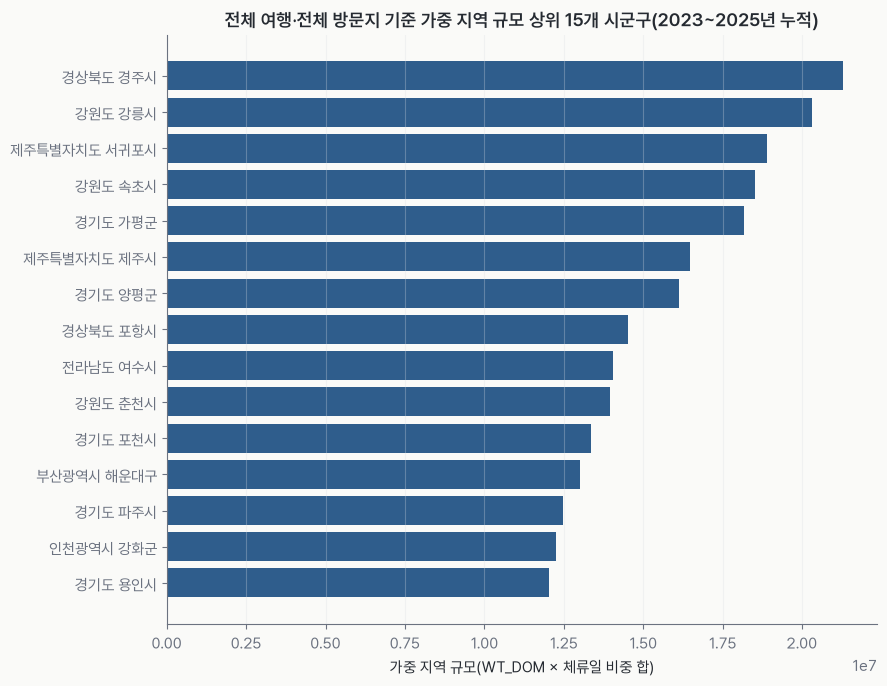

In [14]:
top_n = 15
top_regions = region_visit_totals.head(top_n).copy()
top_regions["표시명"] = top_regions["시도명"] + " " + top_regions["시군구명"]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    top_regions["표시명"][::-1],
    top_regions["가중_지역규모"][::-1],
    color=COLORS["primary"],
)
ax.set_xlabel("가중 지역 규모(WT_DOM × 체류일 비중 합)")
ax.set_title(f"전체 여행·전체 방문지 기준 가중 지역 규모 상위 {top_n}개 시군구(2023~2025년 누적)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "region_visit_totals_top15.png", dpi=900, bbox_inches="tight"
)
plt.show()

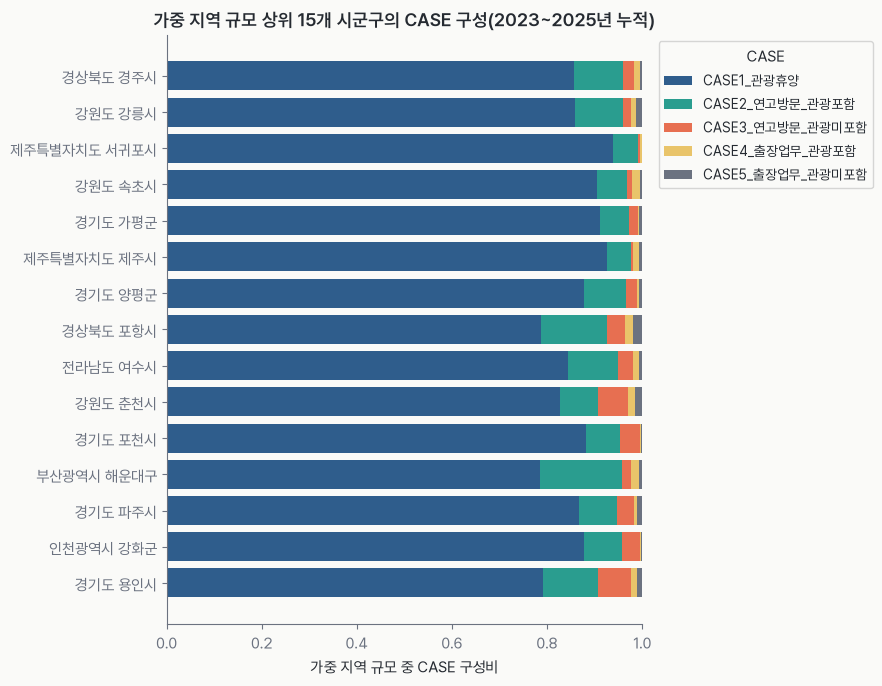

In [15]:
top_case_share = region_visit_totals_by_case.merge(
    top_regions[["시도명", "시군구명", "표시명"]], on=["시도명", "시군구명"]
).set_index("표시명")[list(case_labels.values())]
case_share_ratio = top_case_share.div(top_case_share.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 7))
left = np.zeros(len(case_share_ratio))
for index, case_name in enumerate(case_share_ratio.columns):
    values = case_share_ratio[case_name].to_numpy()
    ax.barh(
        case_share_ratio.index[::-1],
        values[::-1],
        left=left[::-1],
        label=case_name,
        color=PALETTE[index % len(PALETTE)],
    )
    left += values
ax.set_xlabel("가중 지역 규모 중 CASE 구성비")
ax.set_title(f"가중 지역 규모 상위 {top_n}개 시군구의 CASE 구성(2023~2025년 누적)")
ax.legend(title="CASE", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xlim(0, 1)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "region_case_composition_top15.png", dpi=900, bbox_inches="tight"
)
plt.show()

## 12. 핵심 결과와 한계

- `region_visit_totals`/`region_visit_totals_by_case`는 대표 여행
  한정이 아니라 **모든 여행·모든 방문지**를 반영해, 기존 지역
  후보지 선정 노트북이 놓친 CASE 3·5의 방문 지역을 포함한다.
- 지역은 다중응답이라 지역별 소계의 합이 전체 여행 수를 초과할 수
  있다. 반면 CASE는 여행 1건당 배타적 파티션이므로 CASE 소계 합은
  지역별로 전체와 정확히 일치하도록 assert했다.
- "가중 지역 규모"는 `WT_DOM`을 트립 내 지역별 체류일 비중으로 안분한
  값이며, 신고된 여행일수가 아니라 실제로 계산된 방문지별 체류일
  합을 분모로 썼다. 신고값과의 차이는 `validation_summary.csv`에
  남겼다.
- A계열 지역 프로필(`region_a_series_profile.csv`)은 대표 여행
  (CHECK='Y', CASE 1·2·4 한정) 표본에서만 계산했으므로 이 프로필의
  비가중 N·가중 분모는 `region_visit_totals`의 분모와 다르다. A계열
  값은 대표 여행이 방문한 지역 각각에 안분 없이 그대로 배정했다.
- 통합 코드북이 이진·명목·척도를 구분하지 않아 관측값 집합과 명시
  목록으로 자동 분류했다. 계속 이진(0/1)이 아니거나 명시 척도
  목록에 없는 코드형 변수는 모두 명목형(최빈값)으로 처리했으므로,
  표본이 작은 시군구는 최빈값·중앙값 모두 극단값 1~2건에 좌우될 수
  있다.
- 이 결과는 방문 지역과 여행유형·응답 특성의 연관성을 보여줄 뿐,
  정책의 인과효과를 뜻하지 않는다.

In [16]:
print("[국민여행조사 3개년 전체 여행 지역별 집계 요약]")
print(f"- 시군구 수: {len(region_visit_totals)}")
print(f"- 방문 기록이 있는 시군구 수: {int(region_visit_totals['비가중_여행수'].gt(0).sum())}")
print(f"- 전체 트립×지역 행 수(다중응답 포함): {len(trip_region):,}")
print(f"- 대표 여행(A계열 프로필 대상) 수: {len(representative_trips):,}")
print("- 가중 지역 규모 상위 5개 시군구:")
for _, row in region_visit_totals.head(5).iterrows():
    print(
        f"  · {row['시도명']} {row['시군구명']}: "
        f"가중 지역 규모={row['가중_지역규모']:.1f}, "
        f"전국 대비 비중={row['전국_대비_비중(%)']:.2f}%"
    )
print("- 결과표는 region_*, validation_summary, 그림은 region_* 이름으로 저장했습니다.")

[국민여행조사 3개년 전체 여행 지역별 집계 요약]
- 시군구 수: 229
- 방문 기록이 있는 시군구 수: 229
- 전체 트립×지역 행 수(다중응답 포함): 95,079
- 대표 여행(A계열 프로필 대상) 수: 72,133
- 가중 지역 규모 상위 5개 시군구:
  · 경상북도 경주시: 가중 지역 규모=21299212.8, 전국 대비 비중=2.39%
  · 강원도 강릉시: 가중 지역 규모=20305646.8, 전국 대비 비중=2.28%
  · 제주특별자치도 서귀포시: 가중 지역 규모=18905592.3, 전국 대비 비중=2.12%
  · 강원도 속초시: 가중 지역 규모=18537929.2, 전국 대비 비중=2.08%
  · 경기도 가평군: 가중 지역 규모=18171713.0, 전국 대비 비중=2.04%
- 결과표는 region_*, validation_summary, 그림은 region_* 이름으로 저장했습니다.


## 13. 연고관광 사전층화 군집 결과 결합: 시군구 내 군집 구성비

`baseline_stratified_cluster_labeled_data.csv`(사전층화 클러스터링
산출물)는 `YEAR+ID` 단위로 유일하고, `D_TRA_CASE`가 항상 2(관광
활동을 포함한 연고 방문)인 대표 여행 1건에 대한 군집 라벨만 담는다.
실측 검증 결과 이 표의 `YEAR+ID`는 8절 `representative_trips`(대표
여행)의 CASE=2 부분집합과 정확히 일치했다(둘을 `YEAR+ID`로 병합했을 때
빠지는 행이 없었다). 그래서 방문지별 체류일을 다시 계산하지 않고,
`YEAR+ID`로 군집 라벨만 8절 `representative_region`(체류일 비중까지
반영된 `weighted_region_size`를 이미 갖고 있음)에 결합해 재사용한다.

클러스터링이 아직 확정되지 않았으므로 위 환경 설정 셀의
`CLUSTER_LABELED_DATA_PATH`만 최종 결과 파일 경로로 바꾸고 이
노트북을 처음부터 다시 실행하면 이 절 전체가 최신 군집으로
갱신되도록 구성한다. 최종 파일의 표본 범위나 군집 라벨 집합이
달라질 수 있으므로 결합률은 assert가 아니라 QC 출력으로만 남긴다.

In [17]:
cluster_labels = pd.read_csv(
    CLUSTER_LABELED_DATA_PATH, encoding="utf-8-sig", usecols=["ID", "YEAR", "군집"]
)
assert not cluster_labels.duplicated(["YEAR", "ID"]).any(), (
    "군집 결과의 YEAR+ID 키가 중복됩니다."
)

cluster_region = representative_region.merge(
    cluster_labels, on=["YEAR", "ID"], how="inner", validate="many_to_one"
)

matched_id_years = cluster_region[["YEAR", "ID"]].drop_duplicates().shape[0]
print(f"군집 라벨 입력 행 수(YEAR+ID 유일): {len(cluster_labels):,}")
print(f"대표 여행(representative_region)과 결합된 YEAR+ID 수: {matched_id_years:,}")
print(
    "미결합 YEAR+ID 수: "
    f"{len(cluster_labels) - matched_id_years:,}"
    "(대표 여행 정의가 바뀌었거나 클러스터링에서 표본을 추가로 "
    "제외한 경우 발생할 수 있음)"
)
print(f"군집 종류: {sorted(cluster_labels['군집'].dropna().unique().tolist())}")

군집 라벨 입력 행 수(YEAR+ID 유일): 12,790
대표 여행(representative_region)과 결합된 YEAR+ID 수: 12,790
미결합 YEAR+ID 수: 0(대표 여행 정의가 바뀌었거나 클러스터링에서 표본을 추가로 제외한 경우 발생할 수 있음)
군집 종류: ['당일여행 C1', '당일여행 C2', '숙박여행 C1', '숙박여행 C2', '숙박여행 C3']


### 13.1 지역×군집 가중 규모와 구성비

시군구·군집별로 `weighted_region_size`(=`WT_DOM × day_share`)를
합산한 뒤, 시군구 안에서 군집별 값을 그 시군구의 연고관광 가중 규모
합으로 나눠 **행 정규화 구성비**(군집 비중의 합이 1)를 만든다. 이
구성비가 "그 시군구가 연고관광 유형 중 어디에 가까운지"에 대한
답이다. 연고관광 방문 기록이 없는 시군구는 구성비를 계산할 수 없어
`NaN`으로 남긴다.

In [18]:
cluster_labels_sorted = sorted(cluster_region["군집"].dropna().unique().tolist())

region_cluster_weighted = (
    cluster_region.groupby(["시도명", "시군구명", "군집"], as_index=False)
    ["weighted_region_size"].sum()
)
cluster_pivot = (
    region_cluster_weighted.pivot_table(
        index=["시도명", "시군구명"],
        columns="군집",
        values="weighted_region_size",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(columns=cluster_labels_sorted, fill_value=0.0)
)
weighted_columns = [f"군집{label}_가중규모" for label in cluster_labels_sorted]
cluster_pivot.columns = weighted_columns
cluster_pivot = cluster_pivot.reset_index()

region_cluster_wide = region_codes[["시도명", "시군구명"]].merge(
    cluster_pivot, on=["시도명", "시군구명"], how="left"
)
region_cluster_wide[weighted_columns] = region_cluster_wide[weighted_columns].fillna(0.0)

region_total = region_cluster_wide[weighted_columns].sum(axis=1)
region_cluster_wide["연고관광_가중규모_합"] = region_total
has_visits = region_total.gt(0)

share_columns = [f"군집{label}_구성비" for label in cluster_labels_sorted]
for weighted_column, share_column in zip(weighted_columns, share_columns):
    region_cluster_wide[share_column] = np.where(
        has_visits, region_cluster_wide[weighted_column] / region_total, np.nan
    )

share_sum_check = region_cluster_wide.loc[has_visits, share_columns].sum(axis=1)
assert np.allclose(share_sum_check, 1.0, atol=1e-6), (
    "군집 구성비 합이 1이 아닙니다."
)

region_cluster_wide = region_cluster_wide.sort_values(
    "연고관광_가중규모_합", ascending=False
).reset_index(drop=True)

assert len(region_cluster_wide) == 229
region_cluster_wide.to_csv(
    TABLES_DIR / "region_cluster_share.csv", index=False, encoding="utf-8-sig"
)
print(f"연고관광 방문 기록이 있는 시군구 수: {int(has_visits.sum())} / {len(region_cluster_wide)}")
display(region_cluster_wide.head(10).round(3))

연고관광 방문 기록이 있는 시군구 수: 229 / 229


,시도명,시군구명,군집당일여행 C1_가중규모,군집당일여행 C2_가중규모,군집숙박여행 C1_가중규모,군집숙박여행 C2_가중규모,군집숙박여행 C3_가중규모,연고관광_가중규모_합,군집당일여행 C1_구성비,군집당일여행 C2_구성비,군집숙박여행 C1_구성비,군집숙박여행 C2_구성비,군집숙박여행 C3_구성비
0,부산광역시,해운대구,52025.337,834586.357,290060.383,84479.122,936869.759,2198020.958,0.024,0.380,0.132,0.038,0.426
1,경상북도,경주시,73396.586,726035.994,276996.792,62526.713,1006423.388,2145379.473,0.034,0.338,0.129,0.029,0.469
2,전라북도,전주시,124216.060,548147.890,150847.571,64758.644,1230972.263,2118942.429,0.059,0.259,0.071,0.031,0.581
3,경상남도,밀양시,77881.843,835102.268,195621.201,79004.598,870652.560,2058262.471,0.038,0.406,0.095,0.038,0.423
4,강원도,강릉시,17215.767,434413.867,279840.851,78908.333,1212123.966,2022502.784,0.009,0.215,0.138,0.039,0.599
5,경상북도,포항시,7290.895,554254.088,168405.627,114907.197,1158709.498,2003567.306,0.004,0.277,0.084,0.057,0.578
6,대전광역시,유성구,99433.608,729172.126,149877.021,49112.343,525657.729,1553252.828,0.064,0.469,0.096,0.032,0.338
7,강원도,원주시,29659.163,572319.900,165699.615,34048.680,690221.019,1491948.377,0.020,0.384,0.111,0.023,0.463
8,충청남도,공주시,9074.963,784177.317,81331.389,33810.697,573056.317,1481450.684,0.006,0.529,0.055,0.023,0.387
9,전라남도,여수시,103621.421,194685.861,261693.432,41331.453,849304.774,1450636.940,0.071,0.134,0.180,0.028,0.585


### 13.2 시각화: 상위 시군구의 군집 구성비

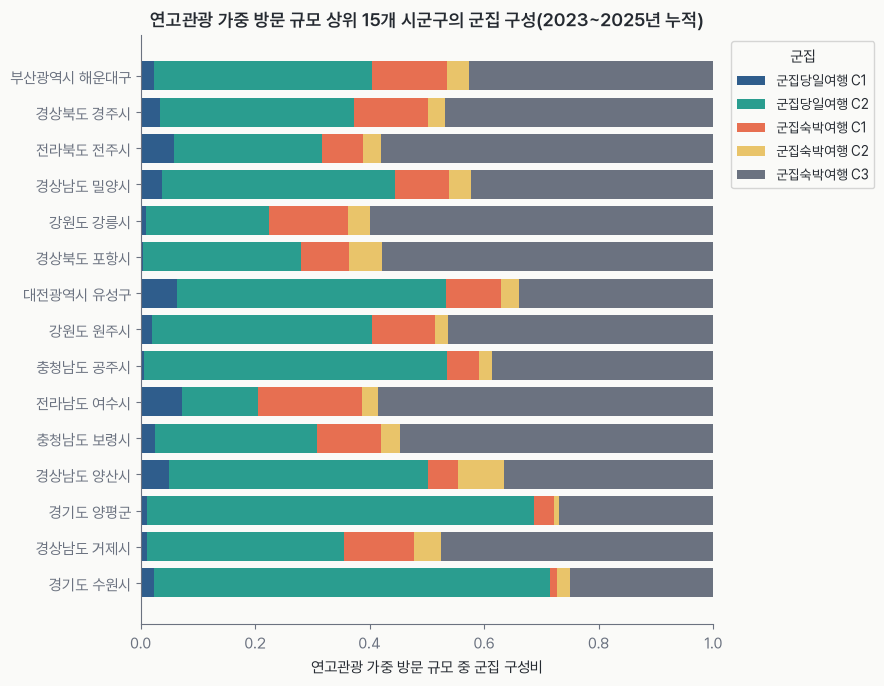

In [19]:
top_n_cluster = 15
top_cluster_regions = region_cluster_wide.loc[has_visits].head(top_n_cluster).copy()
top_cluster_regions["표시명"] = (
    top_cluster_regions["시도명"] + " " + top_cluster_regions["시군구명"]
)

fig, ax = plt.subplots(figsize=(9, 7))
left = np.zeros(len(top_cluster_regions))
for index, share_column in enumerate(share_columns):
    values = top_cluster_regions[share_column].to_numpy()
    ax.barh(
        top_cluster_regions["표시명"][::-1],
        values[::-1],
        left=left[::-1],
        label=share_column.replace("_구성비", ""),
        color=PALETTE[index % len(PALETTE)],
    )
    left += values
ax.set_xlabel("연고관광 가중 방문 규모 중 군집 구성비")
ax.set_title(
    f"연고관광 가중 방문 규모 상위 {top_n_cluster}개 시군구의 군집 구성(2023~2025년 누적)"
)
ax.legend(title="군집", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xlim(0, 1)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "region_cluster_composition_top15.png", dpi=900, bbox_inches="tight"
)
plt.show()

In [20]:
region_trip_feature = region_visit_totals_by_case.merge(
    region_cluster_wide, on=["시도명", "시군구명"], how="left"
).merge(
    region_a_series_profile, on=["시도명", "시군구명"], how="left"
)

assert len(region_trip_feature) == 229
assert not region_trip_feature.duplicated(["시도명", "시군구명"]).any()

print(f"시군구별 통합 특성표 저장: {region_trip_feature.shape[0]}개 시군구 × {region_trip_feature.shape[1]}열")
display(region_trip_feature.head(10).round(3))


시군구별 통합 특성표 저장: 229개 시군구 × 222열


,시도명,시군구명,비가중_여행수,가중_지역규모,전국_대비_비중(%),CASE1_관광휴양,CASE2_연고방문_관광포함,CASE3_연고방문_관광미포함,CASE4_출장업무_관광포함,CASE5_출장업무_관광미포함,...,A9A_11_중앙값,A9A_12_중앙값,A10_중앙값,A11_중앙값,A12_1_중앙값,A12_2_중앙값,A12_3_중앙값,A12_4_중앙값,A12_5_중앙값,A12_6_중앙값
0,경상북도,경주시,2291,2.129921e+07,2.394,1.824898e+07,2183587.381,507180.403,279755.823,79707.591,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
1,강원도,강릉시,1881,2.030565e+07,2.282,1.742448e+07,2072996.178,341429.673,199160.980,267584.294,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
2,제주특별자치도,서귀포시,2578,1.890559e+07,2.125,1.772842e+07,996578.937,101208.723,79388.369,0.000,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
3,강원도,속초시,1734,1.853793e+07,2.084,1.676617e+07,1199468.462,183005.307,301713.143,87576.248,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
4,경기도,가평군,1234,1.817171e+07,2.042,1.657534e+07,1102981.183,340073.715,51093.285,102225.171,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
5,제주특별자치도,제주시,2460,1.646094e+07,1.850,1.523043e+07,829158.084,90465.571,199258.729,111623.973,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
6,경기도,양평군,1082,1.614198e+07,1.814,1.416336e+07,1433606.579,376608.931,76186.162,92216.224,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
7,경상북도,포항시,1680,1.451262e+07,1.631,1.142558e+07,2022552.472,551064.080,222321.657,291104.102,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
8,전라남도,여수시,1783,1.405348e+07,1.580,1.186682e+07,1481470.846,421394.067,198518.396,85278.736,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
9,강원도,춘천시,1172,1.397113e+07,1.570,1.157228e+07,1114505.721,866471.263,195560.827,222314.415,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0


In [21]:
region_trip_feature.to_csv(
    TABLES_DIR / "region_trip_feature.csv", index=False, encoding="utf-8-sig"
)